# LLM expert persona eval analysis

## 🛢️ Data preparation

- Multiple prompt versions have been used to obtain results, but this notebook will only analyse data from the current prompt version.
- The program used to obtain the results has the option to retry parse failures, meaning total parse failures and unique parse failures may be different.
- Sometimes a parse failure occurs for a question under one conditon but not another. To keep things fair, both questions are removed in these cases.

In [1]:
import pandas as pd
from IPython.display import Markdown, display

df = pd.read_json('results.jsonl', lines=True)

# prompt version
current_prompt_version = 'question_v2'
current_prompt_df = df[df['prompt']==current_prompt_version]

print(f'\n\nTotal rows: {len(df)}')
print(f'Total rows for the current prompt version: {len(current_prompt_df)}\n')

display(Markdown('*-- from here all metrics refer to data for the current prompt only --*'))

# parse failures
parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure'])
unique_parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique())
parse_failure_questions = current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique()
filtered_df = current_prompt_df[~current_prompt_df['question'].isin(parse_failure_questions)]
filtered_df.reset_index(inplace=True)
usable_rows = len(filtered_df)
usable_rows_per_condition = len(filtered_df[filtered_df['is_expert']==True])

print(f'\nTotal parse failures: {parse_failures}')
print(f'Total unique parse failures: {unique_parse_failures}')
print(f'Rows removed due to parse failures: {len(current_prompt_df) - usable_rows}')
print(f'\nTotal usable rows: {usable_rows}')
print(f'Total usable rows per condition: {usable_rows_per_condition}\n\n')

filtered_df.head()



Total rows: 401
Total rows for the current prompt version: 397



*-- from here all metrics refer to data for the current prompt only --*


Total parse failures: 1
Total unique parse failures: 1
Rows removed due to parse failures: 1

Total usable rows: 396
Total usable rows per condition: 198




,index,result,category,is_expert,question,correct_answer,llm_answer,asked_at,prompt,model
0,4,fail,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:57:26+00:00,question_v2,gemini-2.5-flash-lite
1,5,pass,law,True,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:57:41+00:00,question_v2,gemini-2.5-flash-lite
2,6,fail,business,True,"Suppose there are 8,000 hours in a year (actua...",G,(C),2026-06-30 16:59:29+00:00,question_v2,gemini-2.5-flash-lite
3,7,pass,computer science,True,"Let a undirected graph G with edges E = {<0,1>...",H,(H),2026-06-30 16:59:45+00:00,question_v2,gemini-2.5-flash-lite
4,8,pass,math,True,What is the value of p in 24 = 2p?,H,(H),2026-06-30 17:00:01+00:00,question_v2,gemini-2.5-flash-lite


## 🔎 Descriptive statistics


Control pass rate: 46.46%
Expert pass rate: 48.99%



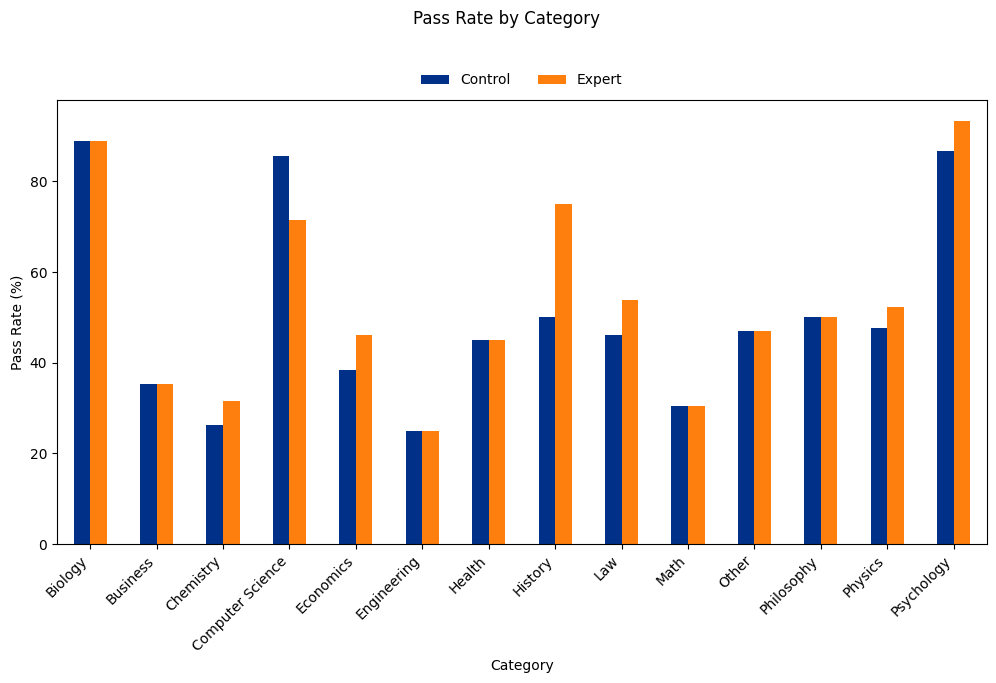

In [5]:
import matplotlib.pyplot as plt

# overall pass rate
control_pass_rate = round(float((filtered_df[filtered_df['is_expert']==False]['result']=='pass').mean()) * 100, 2)
expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==True]['result']=='pass').mean()) * 100, 2)

print(f'\nControl pass rate: {control_pass_rate}%')
print(f'Expert pass rate: {expert_pass_rate}%\n')


# pass rate by category
pass_rate = (
    (filtered_df['result'] == 'pass')
    .groupby([filtered_df['category'], filtered_df['is_expert']])
    .mean()
    * 100
)

plot_df = pass_rate.unstack()

plot_df = plot_df.rename(columns={False: 'Control', True: 'Expert'})

plot_df.index = (
    plot_df.index
    .astype(str)
    .str.replace('_', ' ')
    .str.replace('-', ' ')
    .str.title()
)

fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(kind='bar', ax=ax, color=['#003087', '#FF7F0E'])

ax.set_ylabel('Pass Rate (%)')
ax.set_xlabel('Category')

fig.suptitle('Pass Rate by Category', y=1)

ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=len(plot_df.columns),
    frameon=False
)

plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(top=0.85)

plt.show()

## 🔬 Statistical analysis

In [3]:
from statsmodels.stats.contingency_tables import mcnemar

paired = filtered_df.pivot(
    index='question',
    columns='is_expert',
    values='result'
)

paired.columns = ['Control', 'Expert']

paired = paired.reset_index()
paired.head()

,question,Control,Expert
0,"In Singer's understanding, the principle of t...",fail,fail
1,Select the best translation into predicate lo...,pass,pass
2,"Sirius, one of the hottest known stars, has a...",pass,pass
3,Which Hindu festival involves decorating the ...,pass,pass
4,"""A virulent organism is as good as dead if it ...",pass,pass


In [4]:
table = pd.crosstab(
    paired['Control'],
    paired['Expert']
)

result = mcnemar(table, exact=True)

print('\nStatistic:', result.statistic)
print('p-value:', result.pvalue, '\n')

table


Statistic: 5.0
p-value: 0.30175781249999994 



Expert,fail,pass
Control,,
fail,96,10
pass,5,87
